In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [10]:
df=pd.read_csv("Elderly_Accident_Dataset_final.csv", encoding='cp949')

In [11]:
df[['ED_NA_2022','road_m','NE_2022','market','car']].describe()

,ED_NA_2022,road_m,NE_2022,market,car
count,66.000000,6.600000e+01,66.000000,66.000000,66.000000
mean,227.393939,3.915797e+05,62346.424242,5.681818,0.445455
std,143.944848,3.547720e+05,35253.196433,5.329624,0.134944
min,6.000000,2.998500e+04,6100.000000,0.000000,0.200000
25%,131.000000,1.669712e+05,35133.500000,2.000000,0.400000
50%,196.000000,2.883410e+05,62788.500000,4.500000,0.400000
75%,286.250000,4.777970e+05,79547.750000,6.750000,0.500000
max,586.000000,1.856923e+06,163080.000000,26.000000,1.000000


In [12]:
y = df['ED_NA_2022']  # 노인 운전자 사고건수

X = df[['road_m', 'NE_2022', 'market', 'car']]

In [17]:
y = df['ED_NA_2022']  # 사고건수

# 도로연장길이
X1 = sm.add_constant(df['road_m'])
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

#  노인인구수
X2 = sm.add_constant(df['NE_2022'])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

#  시장개수
X3 = sm.add_constant(df['market'])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:             ED_NA_2022   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     20.46
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.70e-05
Time:                        20:59:56   Log-Likelihood:                -411.97
No. Observations:                  66   AIC:                             827.9
Df Residuals:                      64   BIC:                             832.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        149.1938     23.248      6.418      0.0

In [ ]:
# 단위 면적(예: 1km²)당 도로 연장 길이(m) 계산
df['road_density'] =( df['road_m']*100) / df['area_m2']

# 만약 단위 차이가 너무 크다면 로그 변환을 하거나 단위를 조정해도 좋습니다.
# 예: km 단위로 변환
# df['road_density_km'] = (df['road_m'] / 1000) / df['area']

In [30]:
import statsmodels.api as sm

y = df['ED_NA_2022']  # 노인 운전자 사고건수

X1 = df[['road_density', 'NE_2022', 'market', 'car']]

X = sm.add_constant(X)
model = sm.OLS(y, X1).fit()

print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             ED_NA_2022   R-squared (uncentered):                   0.922
Model:                            OLS   Adj. R-squared (uncentered):              0.917
Method:                 Least Squares   F-statistic:                              183.0
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                    1.39e-33
Time:                        21:11:36   Log-Likelihood:                         -378.65
No. Observations:                  66   AIC:                                      765.3
Df Residuals:                      62   BIC:                                      774.1
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["변수"] = X1.columns
vif_data["VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]

print(vif_data)

             변수       VIF
0  road_density  2.787147
1       NE_2022  4.110695
2        market  2.928870
3           car  2.807329


--- 성남시 지표 순위 ---
              CCD  rank_pop  rank_acc
50  Seongnam City       4.0       3.0


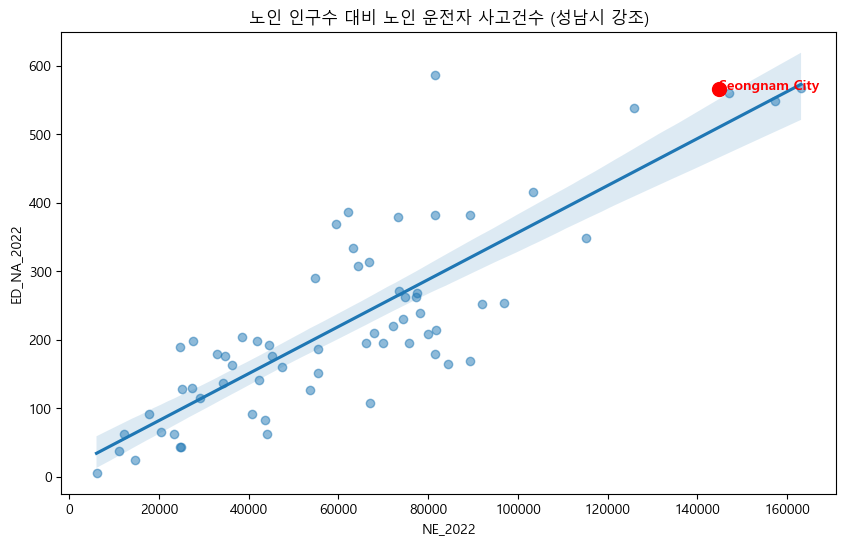

                            OLS Regression Results                            
Dep. Variable:             ED_NA_2022   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     40.01
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.04e-16
Time:                        21:20:03   Log-Likelihood:                -378.64
No. Observations:                  66   AIC:                             767.3
Df Residuals:                      61   BIC:                             778.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.4677     53.487      0.046   

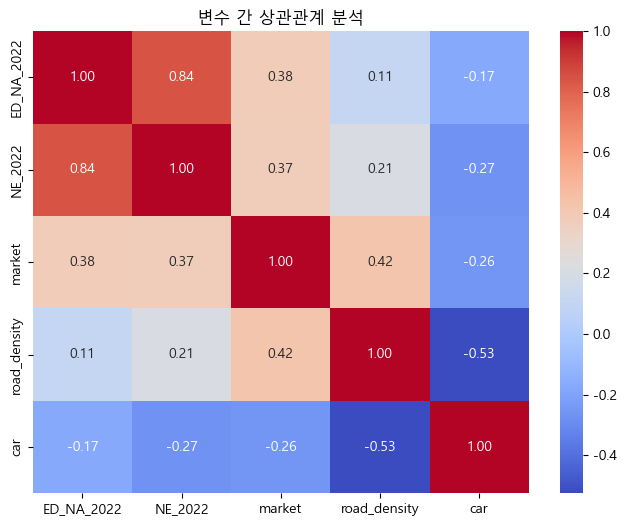

In [36]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 준비 (df에 이미 데이터가 있다고 가정)
# cols = ['region', 'ED_NA_2022', 'NE_2022', 'market', 'road_m', 'area_m2', 'car']
# region 컬럼에 '성남시' 또는 '수정구', '중원구', '분당구'가 포함되어 있어야 합니다.

# 2. 성남시 순위 파악
df['rank_pop'] = df['NE_2022'].rank(ascending=False)       # 노인인구수 순위
df['rank_acc'] = df['ED_NA_2022'].rank(ascending=False)    # 사고건수 순위

seongnam_data = df[df['CCD'].str.contains('Seongnam')]
print("--- 성남시 지표 순위 ---")
print(seongnam_data[['CCD', 'rank_pop', 'rank_acc']])

# 3. 파생 변수 생성 (도로 밀도)
df['road_density'] = (df['road_m'] * 100) / df['area_m2']

# 4. 단순 회귀 분석 및 시각화 (노인인구 vs 사고건수)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='NE_2022', y='ED_NA_2022', scatter_kws={'alpha':0.5})

# 회귀선 위 성남시 강조 표시
for i in range(len(df)):
    if 'Seongnam' in df.loc[i, 'CCD']:
        plt.text(df.loc[i, 'NE_2022'], df.loc[i, 'ED_NA_2022'], 
                 df.loc[i, 'CCD'], color='red', fontweight='bold')
        plt.scatter(df.loc[i, 'NE_2022'], df.loc[i, 'ED_NA_2022'], color='red', s=100)

plt.title('노인 인구수 대비 노인 운전자 사고건수 (성남시 강조)')
plt.show()

# 5. 다중 회귀 분석 (OLS)
X = df[['NE_2022', 'market', 'road_density', 'car']]
X = sm.add_constant(X) # 상수항 추가
y = df['ED_NA_2022']

model = sm.OLS(y, X).fit()
print(model.summary())

# 6. 상관관계 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(df[['ED_NA_2022', 'NE_2022', 'market', 'road_density', 'car']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('변수 간 상관관계 분석')
plt.show()